# SPY Data Acquisition, Storage, Preprocessing, and Outlier Pipeline

This cumulative Stage 04–07 pipeline acquires adjusted daily SPY OHLCV data, validates and reconciles raw storage, creates a deterministic processed dataset, and reports outlier sensitivity without silently removing market shocks.

## Setup

In [1]:
from pathlib import Path
import os, sys

if Path.cwd().name == 'notebooks':
    os.chdir('..')
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print('working from:', ROOT.name)

working from: project


## Parameters and source

- Source: Yahoo Finance historical market data via the `yfinance` client
- Instrument: SPY (broad U.S. equity-market ETF proxy)
- Frequency: daily, with `auto_adjust=True`
- Source page: https://finance.yahoo.com/quote/SPY/history/

The open-ended end date intentionally refreshes to the latest available trading day.

In [2]:
from src.config import load_env

load_env()
SYMBOL = 'SPY'
START_DATE = '2015-01-01'
END_DATE = None
print({'symbol': SYMBOL, 'start': START_DATE, 'end': END_DATE})

{'symbol': 'SPY', 'start': '2015-01-01', 'end': None}


## Acquire and validate

In [3]:
from src.ingestion import download_daily_prices, validate_market_data

prices = download_daily_prices(SYMBOL, START_DATE, END_DATE)
validate_market_data(prices)
print('rows:', len(prices))
print('date range:', prices['date'].min().date(), 'to', prices['date'].max().date())
print('columns:', prices.columns.tolist())
print('missing values:', prices.isna().sum().to_dict())
print('duplicate dates:', int(prices['date'].duplicated().sum()))
prices.head()

rows: 2925
date range: 2015-01-02 to 2026-08-20
columns: ['date', 'open', 'high', 'low', 'close', 'volume']
missing values: {'date': 0, 'open': 0, 'high': 0, 'low': 0, 'close': 0, 'volume': 0}
duplicate dates: 0


,date,open,high,low,close,volume
0,2015-01-02,170.472512,170.885518,168.655274,169.687790,121465900
1,2015-01-05,168.647066,168.812266,166.317716,166.623337,169632600
2,2015-01-06,166.928950,167.449342,164.260931,165.053909,209151400
3,2015-01-07,166.375491,167.449310,165.929449,167.110641,125346700
4,2015-01-08,168.514886,170.290821,168.498375,170.076050,147217800


### Validation logic

The reusable validator requires at least 20 rows, exact ordered columns, unique increasing dates, nonmissing positive OHLC prices, and nonnegative volume. A download that returns successfully but violates any rule fails the pipeline.

## Store and reconcile

In [4]:
from src.storage import resolve_data_dir, save_raw_snapshot, verify_storage_round_trip

data_dir = resolve_data_dir(ROOT)
csv_path, parquet_path = save_raw_snapshot(prices, SYMBOL, data_dir)
verify_storage_round_trip(prices, csv_path, parquet_path)
for path in (csv_path, parquet_path):
    print(path.relative_to(ROOT), f'{path.stat().st_size:,} bytes')
print('CSV and Parquet both reconcile with the validated source frame.')

data/raw/spy_daily.csv 273,427 bytes
data/raw/spy_daily.parquet 151,791 bytes
CSV and Parquet both reconcile with the validated source frame.


## Checks and limitations

Yahoo Finance is a convenient course-scale source, not a contractual institutional feed. Availability, schema, adjustments, and historical observations may change. The raw snapshot is therefore validated and stored in two formats, but it should be re-acquired and compared before consequential use.

In [5]:
assert len(prices) > 1_000
assert prices['date'].is_monotonic_increasing and prices['date'].is_unique
assert (prices[['open', 'high', 'low', 'close']] > 0).all().all()
assert csv_path.is_file() and parquet_path.is_file()
print('All Stage 04–05 pipeline checks passed.')

All Stage 04–05 pipeline checks passed.


## Stage 06 — Deterministic preprocessing

The preprocessing contract parses and validates the canonical OHLCV schema,
resolves duplicate dates deterministically, rejects invalid prices or volume,
and derives close-to-close log returns. Missing volume uses a median only when
at least one finite observation exists; missing prices are not invented.

In [6]:
import numpy as np
from src.cleaning import preprocess_market_data

processed = preprocess_market_data(prices)
processed_dir = data_dir / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)
processed_csv = processed_dir / "spy_daily_clean.csv"
processed_parquet = processed_dir / "spy_daily_clean.parquet"
processed.to_csv(processed_csv, index=False)
processed.to_parquet(processed_parquet, index=False)
print("processed rows:", len(processed))
print("processed date range:", processed["date"].min().date(), "to", processed["date"].max().date())
print("missing values:", processed.isna().sum().to_dict())
processed.tail()

processed rows: 2924
processed date range: 2015-01-05 to 2026-08-20
missing values: {'date': 0, 'open': 0, 'high': 0, 'low': 0, 'close': 0, 'volume': 0, 'log_return': 0}


,date,open,high,low,close,volume,log_return
2919,2026-08-14,778.539978,778.799988,775.429993,776.340027,31367900.0,-0.001982
2920,2026-08-17,776.179993,776.780029,772.510010,772.669983,34356600.0,-0.004739
2921,2026-08-18,768.700012,769.500000,766.919983,767.450012,43920900.0,-0.006779
2922,2026-08-19,770.359985,772.469971,768.099976,769.059998,40242400.0,0.002096
2923,2026-08-20,765.960022,767.750000,765.359985,766.719971,8978234.0,-0.003047


## Stage 07 — Outlier flags and sensitivity

IQR and Z-score flags are diagnostics. Market shocks may be genuine risk
information, so the untreated return remains canonical and filtering plus
winsorization appear only as explicit sensitivity cases.

/var/folders/dw/c8s1528153ncqpv4jf_p2j6m0000gn/T/ipykernel_72777/3012966072.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(flagged["log_return"], vert=False)


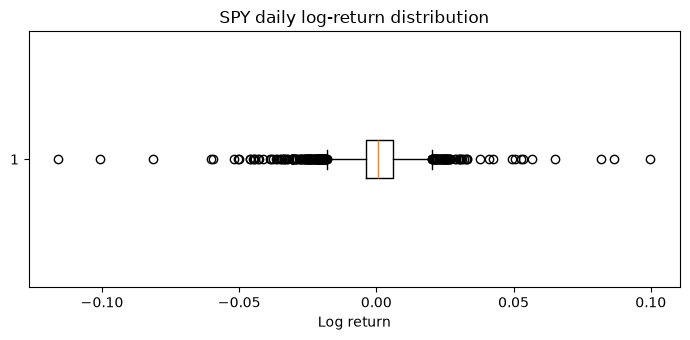

{'iqr_flags': 188, 'zscore_flags': 40}


,count,mean,median,std
all,2924,0.000516,0.000645,0.011104
filtered_iqr,2736,0.001051,0.000784,0.007324
winsorized,2924,0.000627,0.000645,0.008116


In [7]:
import matplotlib.pyplot as plt
from src.outliers import flag_outliers, sensitivity_summary

flagged = flag_outliers(processed, "log_return", method="iqr", flag_column="outlier_iqr")
flagged = flag_outliers(flagged, "log_return", method="zscore", flag_column="outlier_z")
sensitivity = sensitivity_summary(flagged["log_return"], flagged["outlier_iqr"])

reports_dir = ROOT / "reports"
reports_dir.mkdir(parents=True, exist_ok=True)
sensitivity_path = reports_dir / "outlier_sensitivity.csv"
sensitivity.to_csv(sensitivity_path)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.boxplot(flagged["log_return"], vert=False)
ax.set(title="SPY daily log-return distribution", xlabel="Log return")
fig.tight_layout()
outlier_plot_path = reports_dir / "outlier_log_return_boxplot.png"
fig.savefig(outlier_plot_path, dpi=160, bbox_inches="tight")
plt.show()

print({"iqr_flags": int(flagged["outlier_iqr"].sum()), "zscore_flags": int(flagged["outlier_z"].sum())})
sensitivity

### Interpretation and risk

Differences across the three summaries quantify how much tail observations
affect scale and center. An apparently smoother filtered series is not
automatically better: removing real shocks would understate the risk the
project is intended to monitor. The full policy is in `docs/outliers.md`.

In [8]:
assert len(processed) == len(prices) - 1
assert processed["date"].is_monotonic_increasing and processed["date"].is_unique
assert np.isfinite(processed["log_return"]).all()
assert not processed.isna().any().any()
assert flagged[["outlier_iqr", "outlier_z"]].dtypes.eq(bool).all()
assert processed_csv.is_file() and processed_parquet.is_file()
assert sensitivity_path.is_file() and outlier_plot_path.is_file()
print("All Stage 06–07 pipeline checks passed.")

All Stage 06–07 pipeline checks passed.
